# CryptoStatArb — Research Notebook

**Statistical Arbitrage in Cryptocurrencies** (WSQ Course Project)

Goal: research profitable **momentum and/or reversal** strategies on crypto,
backtest unconstrained, apply realistic execution costs (Binance.US, Tier 1),
and evaluate returns / vol / Sharpe / max drawdown / alpha-beta.

Exchange: [Binance.US](https://www.binance.us/fees)

In [1]:
# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Canonical dataset — build once via download_data.ipynb, then load here:
DATA_DIR = Path('data')
# panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
# close, volume = panel['Close'], panel['Volume']
# ret = close.pct_change()

In [2]:
# --- Binance.US commission (published standard rates, checked 2026-08-27) ---
FEES = {
    'maker_bps': 0.0,      # 0.00%  limit orders that ADD liquidity
    'taker_bps': 2.0,      # 0.02%  market orders that TAKE liquidity
    'bnb_discount': 0.05,  # 5% off maker & taker when fees paid in BNB
}

# Course-project baseline (from ClassProject brief) for cross-checking backtests:
#   market order = 7 bps commission + 13 bps assumed slippage = 20 bps all-in
#   limit order  = 7 bps commission only
PROJECT_COST_ASSUMPTION = {
    'commission_bps': 7.0,
    'slippage_bps': 13.0,
    'market_all_in_bps': 20.0,
    'limit_bps': 7.0,
}

# Asset-dependent costs (half-spread, impact) are filled in per symbol later, e.g.:
#   SYMBOL_TCOSTS = {'BTCUSDT': {'half_spread_bps': ..., 'impact_bps': ...}, ...}
SYMBOL_TCOSTS = {}

def bps(x):
    """basis points -> decimal (e.g. 20 -> 0.0020)."""
    return x / 1e4

FEES

{'maker_bps': 0.0, 'taker_bps': 2.0, 'bnb_discount': 0.05}

## Performance & Risk Metrics (reusable helpers)

Conventions match the WSQ lectures. Inputs:
- `strat_ret` — per-bar strategy **return** Series.
- `port` — the **weights** DataFrame (time × asset) used for turnover.
- `benchmark` — a market return Series (e.g. equal-weight universe) for beta.
- `ann` — periods per year for annualization: hourly `24*365`; b-hour `24*365/b`.

In [3]:
# --- Performance & risk metrics ---------------------------------------------
ANN_HOURLY = 24 * 365   # bars per year for hourly data (crypto trades 24/7)

def sharpe(ret, ann=ANN_HOURLY):
    """Annualized Sharpe ratio of a per-period return series."""
    return ret.mean() / ret.std() * np.sqrt(ann)

def drawdown(equity):
    """Drawdown series from an equity/price curve (WSQ convention)."""
    return equity / equity.expanding(min_periods=1).max() - 1

def equity_curve(ret):
    """Compounded equity from per-period returns (starts at 1)."""
    return (1 + ret.fillna(0)).cumprod()

def max_drawdown(ret):
    """Worst peak-to-trough drawdown (a negative number)."""
    return drawdown(equity_curve(ret)).min()

def max_dd_duration(ret):
    """Longest underwater stretch in BARS (peak until a new high is made)."""
    eq = equity_curve(ret)
    underwater = eq < eq.expanding(min_periods=1).max()
    return int(underwater.groupby((~underwater).cumsum()).cumsum().max())

def turnover(port):
    """Per-period turnover: sum_i |w_it - w_i,t-1|  (WSQ formula). Returns a Series."""
    return (port.fillna(0) - port.shift().fillna(0)).abs().sum(1)

def beta(strat_ret, benchmark_ret):
    """Market beta = OLS slope of strategy returns on a benchmark return series."""
    d = pd.concat([strat_ret, benchmark_ret], axis=1).dropna()
    X = sm.add_constant(d.iloc[:, 1])
    return sm.OLS(d.iloc[:, 0], X).fit().params.iloc[1]

def beta_contribution(strat_ret, benchmark_ret):
    """The beta * benchmark component of returns (the 'market' part of P&L)."""
    return beta(strat_ret, benchmark_ret) * benchmark_ret

def performance_summary(strat_ret, port=None, benchmark=None, ann=ANN_HOURLY, name='strategy'):
    """One-row summary of all key metrics for a strategy return series."""
    s = {
        'ann_return':      strat_ret.mean() * ann,
        'ann_vol':         strat_ret.std() * np.sqrt(ann),
        'sharpe':          sharpe(strat_ret, ann),
        'avg_turnover':    turnover(port).mean() if port is not None else np.nan,
        'max_drawdown':    max_drawdown(strat_ret),
        'max_dd_dur_bars': max_dd_duration(strat_ret),
        'beta':            beta(strat_ret, benchmark) if benchmark is not None else np.nan,
    }
    return pd.Series(s, name=name)

def summary_table(strats, ports=None, benchmark=None, ann=ANN_HOURLY):
    """Metrics table (rows = strategies) from a dict {name: return_series}.
       `ports`: optional {name: weights_df};  `ann`: scalar or {name: ann}."""
    rows = []
    for nm, r in strats.items():
        p = ports.get(nm) if isinstance(ports, dict) else None
        a = ann.get(nm, ANN_HOURLY) if isinstance(ann, dict) else ann
        rows.append(performance_summary(r, p, benchmark, a, nm))
    return pd.DataFrame(rows)

print('metrics ready:', [f.__name__ for f in
      (sharpe, drawdown, max_drawdown, max_dd_duration, turnover, beta, performance_summary, summary_table)])

metrics ready: ['sharpe', 'drawdown', 'max_drawdown', 'max_dd_duration', 'turnover', 'beta', 'performance_summary', 'summary_table']


### Using the metrics

```python
mkt = ret.mean(axis=1)                       # equal-weight 'market' benchmark

# one strategy:
performance_summary(strat_ret, port, benchmark=mkt, ann=24*365)

# several at once (e.g. per holding interval) -> a table:
summary_table({'1h': r1, '2h': r2},
              ports={'1h': p1, '2h': p2},
              benchmark=mkt,
              ann={'1h': 24*365, '2h': 24*365/2})
```
For a b-hour strategy set `ann = 24*365/b`. `max_dd_dur_bars` is in bars — multiply by the
bar length for wall-clock time.

## Data & Log Prices

Load the canonical panel (built by `download_data.ipynb`), resample to **daily** closes, and take **log prices** (then log returns) — the base series for all the EDA below.

In [4]:
# --- Daily log prices for all coins (resample hourly UTC close -> daily close) ---
# Daily (not hourly) so the ADF test isn't drowned in 40k obs of excess power.
close = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close']
dclose = close.resample('1D').last()
logpx = np.log(dclose)
print('daily log-price panel:', logpx.shape, '|', logpx.index.min().date(), '->', logpx.index.max().date())
logpx.tail()

daily log-price panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,-2.3925,4.8808,-1.5079,-2.3919,-1.9235,-1.4524,0.4200,-4.3306,2.0200,-0.0182,...,-1.4740,1.4490,-5.1678,-5.6840,-7.8833,-1.6439,7.8528,6.7202,1.6956,-2.3157
2026-08-25 00:00:00+00:00,-2.3570,4.8347,-1.5649,-2.4137,-1.9604,-1.4524,0.4167,-4.3709,1.9912,0.0583,...,-1.6296,1.4351,-5.1795,-5.6840,-7.9074,-1.7019,7.8528,6.6436,1.6292,-2.3486
2026-08-26 00:00:00+00:00,-2.3623,4.8363,-1.5481,-2.4088,-1.9733,-1.4524,0.4095,-4.3725,2.0081,-0.0471,...,-1.5995,1.4791,-5.0046,-5.6840,-7.8240,-1.6870,7.6563,6.7049,1.6094,-2.3026
2026-08-27 00:00:00+00:00,-2.3570,4.8577,-1.5421,-2.3928,-1.9442,-1.4524,0.4511,-4.3103,2.0189,-0.0141,...,-1.5945,1.5510,-4.9362,-5.6840,-7.7848,-1.6738,7.6563,6.6967,1.6974,-2.3056
2026-08-28 00:00:00+00:00,-2.4453,4.8112,-1.5941,-2.4421,-1.9885,-1.4439,0.3743,-4.2708,1.9844,-0.0141,...,-1.6503,1.4893,-5.0056,-5.6840,-7.8291,-1.7217,7.6563,6.6727,1.5933,-2.3549


## Exploratory Data Analysis

Understand the universe before any strategy work:
1. **Log returns** — `logret = logpx.diff()`, daily continuously-compounded returns.
2. **Price history** — raw daily close for all 60 coins (small multiples).
3. **Return correlation** — Pearson correlation of daily log returns, on a heatmap.
4. **Intraday structure (GAM)** — seasonality of absolute *and signed* returns, volume, and volatility over hour-of-day × weekday.
5. **Real order-book spread** — live best bid/ask per coin → true intraday illiquidity, the *tradeable* universe, and how the spread moves over time.

This notebook is intentionally EDA-only. Strategy experiments (reversal, momentum, intraday
predictability) were explored and set aside — see [`docs/strategy_log.md`](docs/strategy_log.md) for the
full log of what was tried and why each was parked or dropped.

In [5]:
# --- Daily log returns for all coins:  r_t = log(P_t) - log(P_{t-1}) ---
logret = logpx.diff()
print('daily log-return panel:', logret.shape, '|',
      logret.index.min().date(), '->', logret.index.max().date())
logret.tail()

daily log-return panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,0.0379,-0.0696,-0.0260,-0.0297,-0.0210,0.0662,-0.0562,0.0411,-0.0098,0.0696,...,-0.0216,-0.0584,-0.0162,0.0606,0.0107,-0.0329,0.0746,-0.0284,0.0450,-0.0446
2026-08-25 00:00:00+00:00,0.0355,-0.0461,-0.0570,-0.0219,-0.0370,0.0000,-0.0033,-0.0403,-0.0288,0.0764,...,-0.1556,-0.0139,-0.0117,0.0000,-0.0242,-0.0580,0.0000,-0.0766,-0.0664,-0.0330
2026-08-26 00:00:00+00:00,-0.0053,0.0016,0.0168,0.0049,-0.0129,0.0000,-0.0073,-0.0016,0.0169,-0.1054,...,0.0302,0.0440,0.1749,0.0000,0.0834,0.0149,-0.1965,0.0612,-0.0198,0.0460
2026-08-27 00:00:00+00:00,0.0053,0.0214,0.0060,0.0160,0.0291,0.0000,0.0416,0.0622,0.0108,0.0330,...,0.0049,0.0719,0.0684,0.0000,0.0392,0.0132,0.0000,-0.0081,0.0880,-0.0030
2026-08-28 00:00:00+00:00,-0.0883,-0.0465,-0.0520,-0.0492,-0.0443,0.0085,-0.0768,0.0394,-0.0345,0.0000,...,-0.0557,-0.0617,-0.0695,0.0000,-0.0442,-0.0478,0.0000,-0.0240,-0.1041,-0.0493


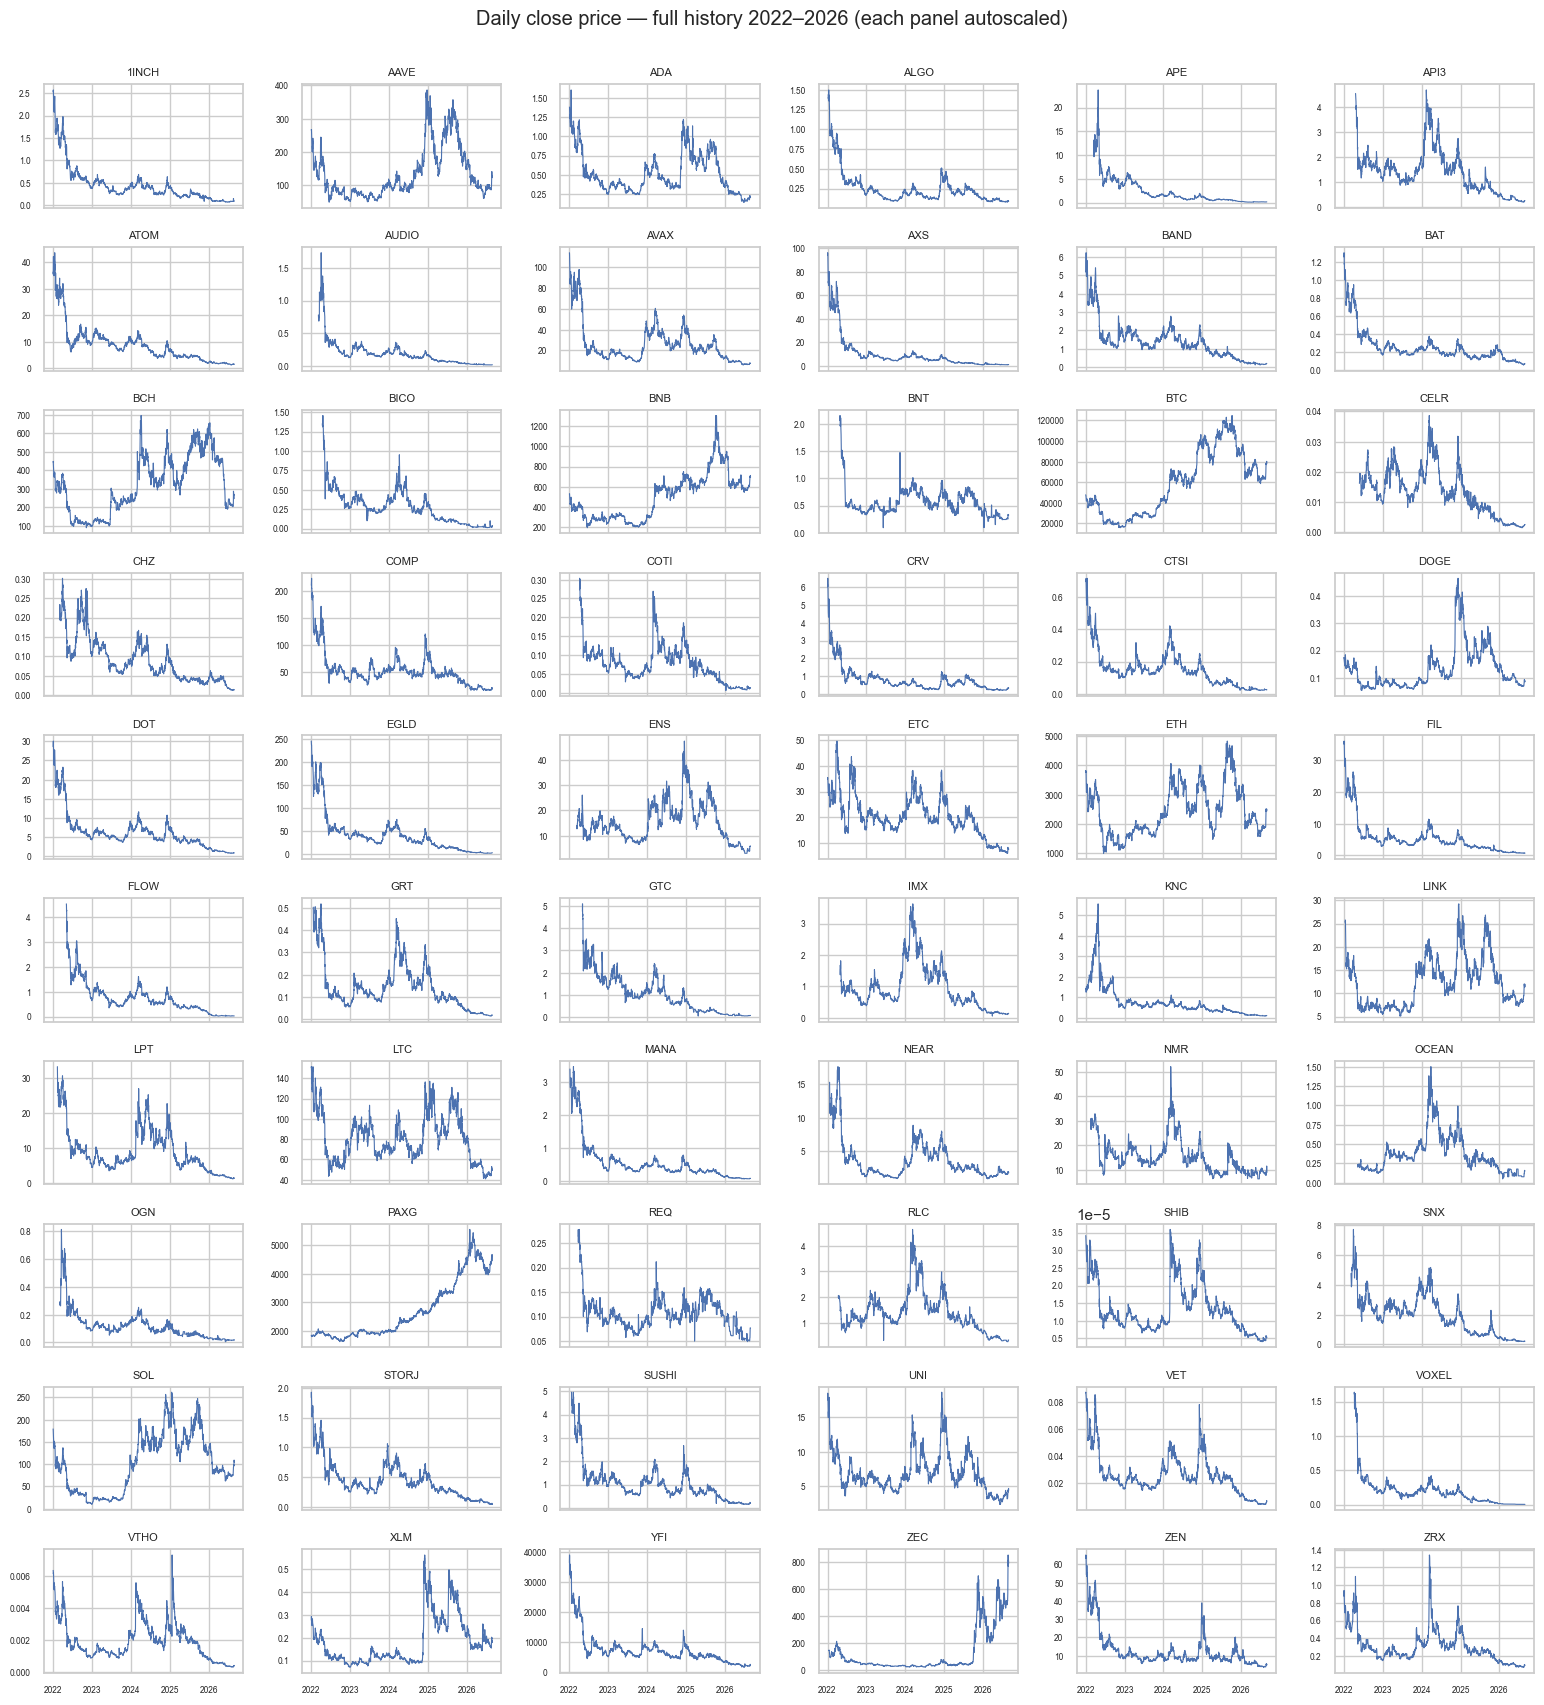

In [6]:
# --- Raw daily close price, full history, one panel per coin ---
# Own y-axis per panel: prices span BTC ~1e5 down to SHIB ~1e-5, so a shared axis is useless.
cols = list(dclose.columns)
ncol = 6
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.6, nrow * 1.7), sharex=True)
for ax, c in zip(axes.flat, cols):
    ax.plot(dclose.index, dclose[c], lw=0.8)
    ax.set_title(c.replace('USDT', ''), fontsize=8)
    ax.tick_params(labelsize=6)
for ax in axes.flat[len(cols):]:
    ax.axis('off')
fig.suptitle('Daily close price — full history 2022–2026 (each panel autoscaled)', y=1.002)
fig.tight_layout()
plt.show()

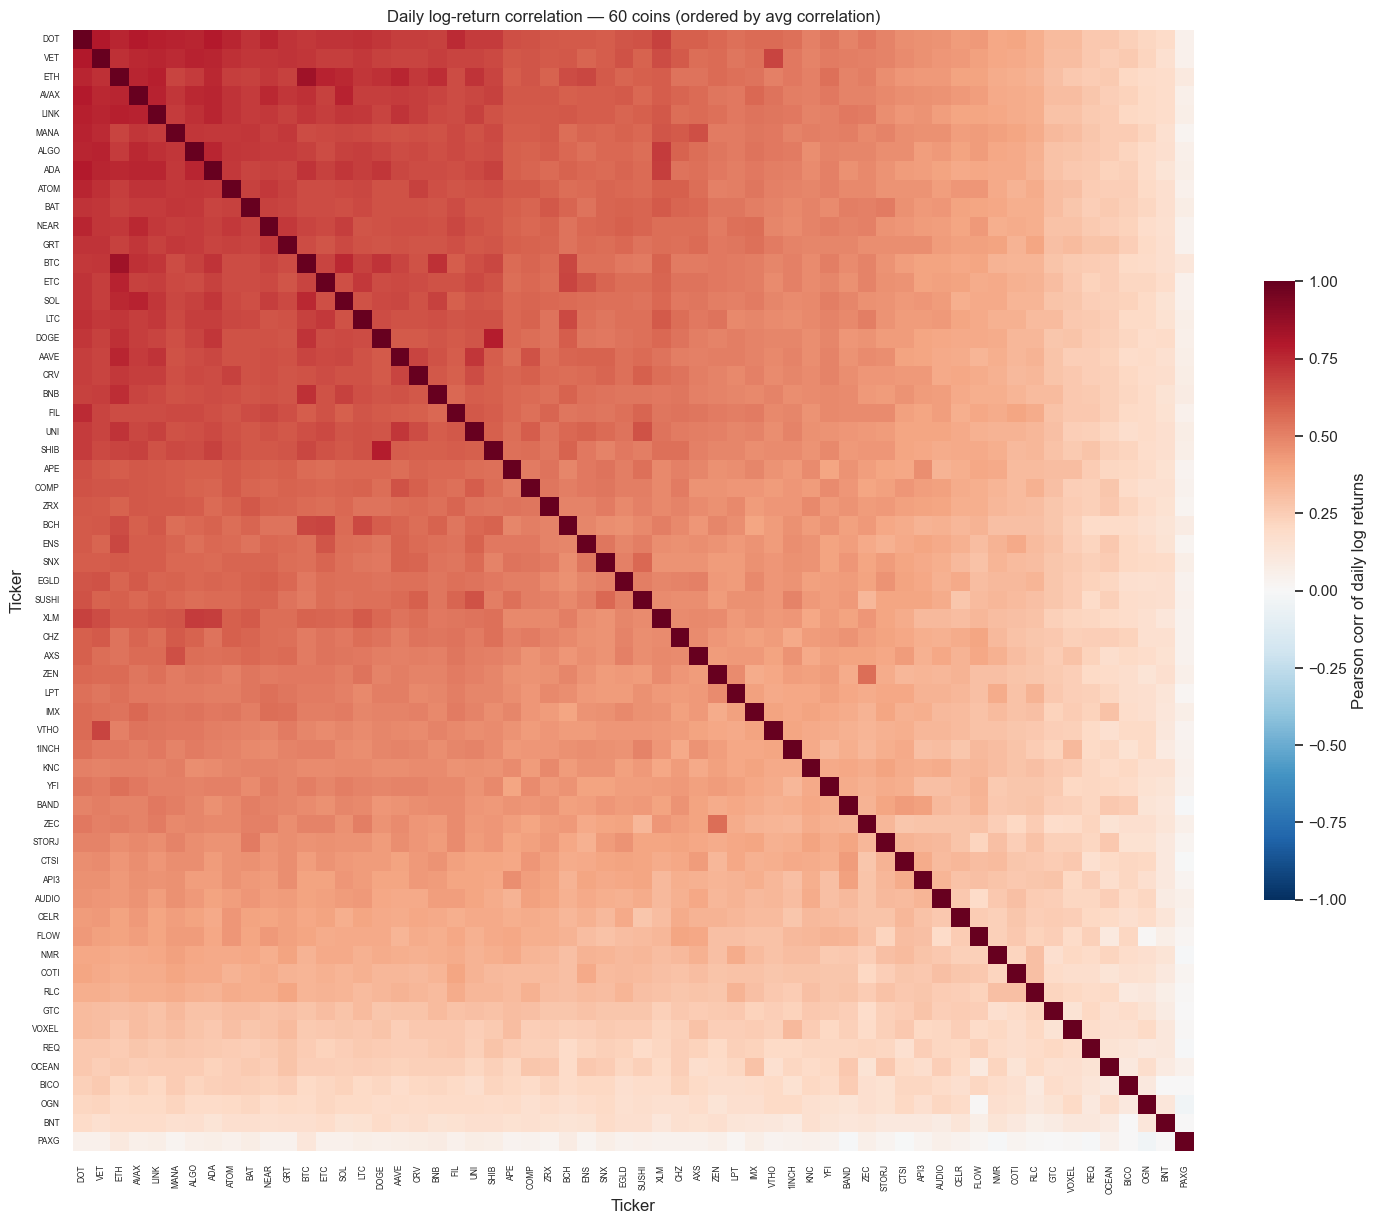

mean pairwise corr = 0.421 | min = -0.035 | max = 0.846


In [7]:
# --- Correlation matrix of daily log returns across all 60 coins ---
corr = logret.corr()
# order by average correlation so the tightly-coupled majors cluster into a visible block
order = corr.mean().sort_values(ascending=False).index
corr = corr.loc[order, order]
labels = [c.replace('USDT', '') for c in corr.columns]

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Pearson corr of daily log returns', 'shrink': 0.5}, ax=ax)
ax.set_title('Daily log-return correlation — 60 coins (ordered by avg correlation)')
ax.tick_params(labelsize=6)
fig.tight_layout()
plt.show()

offdiag = corr.values[np.triu_indices_from(corr, k=1)]
print(f'mean pairwise corr = {offdiag.mean():.3f} | min = {offdiag.min():.3f} | max = {offdiag.max():.3f}')

## Intraday seasonality via GAM (Härdle et al., "Rise of the Machines")

Reproducing the paper's intraday high-frequency visuals on our **hourly** data (theirs was 5-min),
for the majors **BTC, ETH, XRP, SOL, LTC**. A Generalized Additive Model smooths a noisy quantity
against a *time coordinate*:

- **Absolute returns** vs hour-of-day and vs weekday — 1D cubic-spline smooths with CI bands (paper Figs 7–8).
- **Trading volume** as a 2D **surface** over (hour-of-day × weekday) — tensor-product smooth (paper Fig 9).
- **Volatility** (Parkinson high–low range) as the same 2D surface (paper Fig 10).

The paper's thesis: if trading were purely algorithmic/24-7, these surfaces would be flat. The humps
at working hours / weekdays are the "proof of human." Times here are **UTC** (the paper used +1 GMT).
Requires `pygam` (`pip install pygam`); **XRP** is loaded from a side file since it's not in the main panel.

{'BTC': 40811, 'ETH': 40811, 'XRP': 27392, 'SOL': 40811, 'LTC': 40811} hourly rows per coin


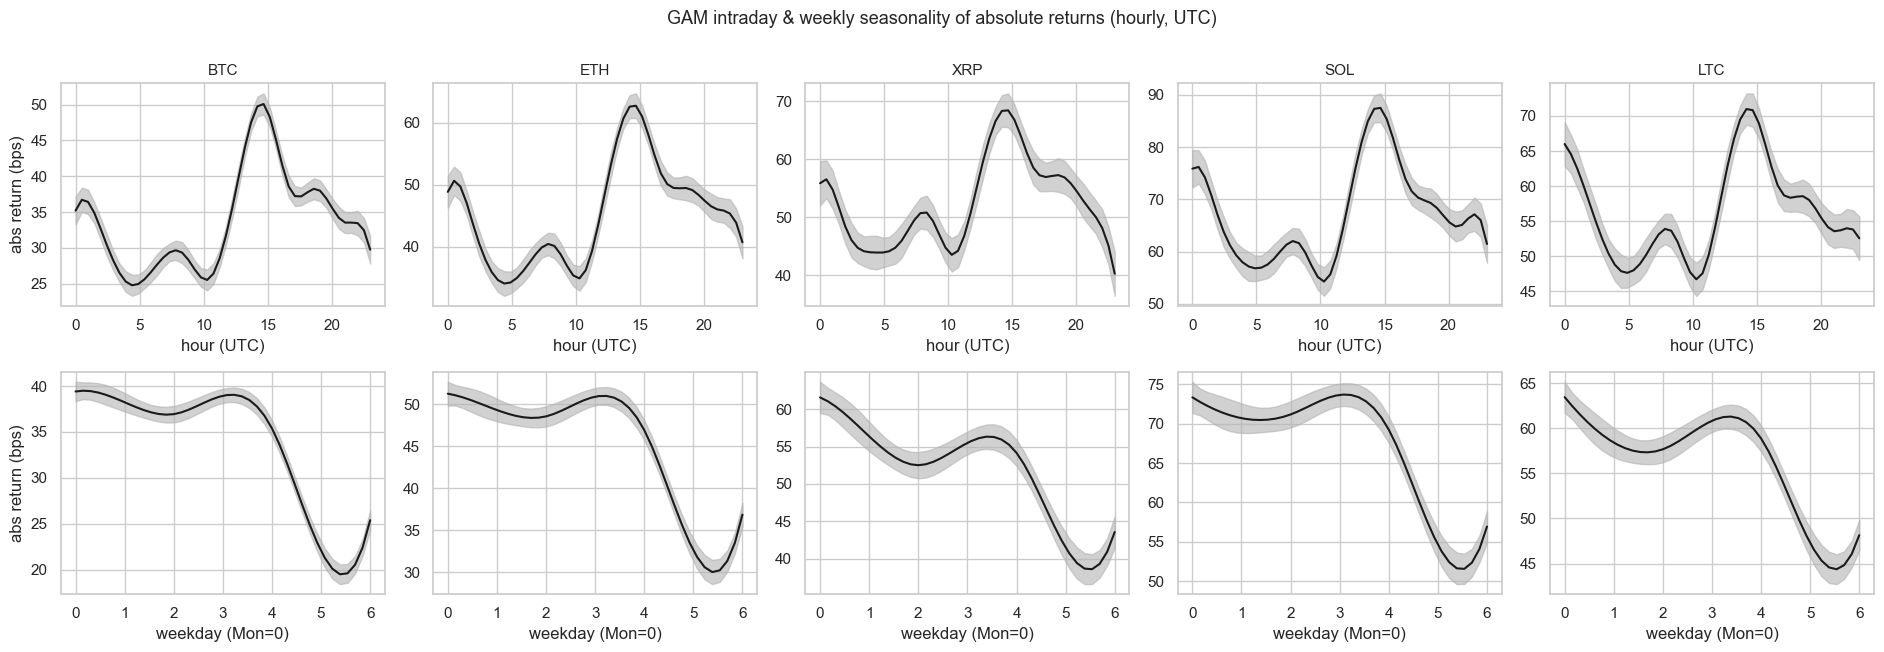

In [8]:
# --- GAM setup: per-coin hourly frame (returns / Parkinson vol / volume, hour, weekday) ---
import warnings; warnings.filterwarnings('ignore')
from pygam import LinearGAM, s, te
from matplotlib import cm

panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
GAM_COINS = ['BTC', 'ETH', 'XRP', 'SOL', 'LTC']

def coin_frame(tk):
    """Hourly OHLCV -> abs return, Parkinson range-vol, volume, plus hour & weekday coords."""
    d = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk') if tk == 'XRP'
         else panel.xs(tk + 'USDT', axis=1, level='Ticker')[['Open','High','Low','Close','Volume']])
    d = d.dropna(subset=['Close'])
    f = pd.DataFrame(index=d.index)
    f['abs_ret'] = np.log(d.Close).diff().abs()
    f['parkvol'] = np.sqrt((np.log(d.High / d.Low) ** 2) / (4 * np.log(2)))   # Parkinson HL vol
    f['volume']  = d.Volume
    f['hour']    = d.index.hour
    f['wday']    = d.index.dayofweek                                          # Mon=0 .. Sun=6
    return f.dropna()

gam_frames = {c: coin_frame(c) for c in GAM_COINS}
print({c: gam_frames[c].shape[0] for c in GAM_COINS}, 'hourly rows per coin')

# --- Fig 7/8: daily & weekly GAM seasonality of ABSOLUTE RETURNS (with CI bands) ---
fig, axes = plt.subplots(2, 5, figsize=(19, 6.5))
for j, c in enumerate(GAM_COINS):
    f = gam_frames[c]
    g = LinearGAM(s(0, n_splines=14)).fit(f[['hour']].values, f['abs_ret'].values * 1e4)
    xx = g.generate_X_grid(term=0, n=48); ci = g.confidence_intervals(xx)
    ax = axes[0, j]; ax.plot(xx[:, 0], g.predict(xx), 'k')
    ax.fill_between(xx[:, 0], ci[:, 0], ci[:, 1], color='0.7', alpha=.6)
    ax.set_title(c, fontsize=11); ax.set_xlabel('hour (UTC)')
    if j == 0: ax.set_ylabel('abs return (bps)')
    g2 = LinearGAM(s(0, n_splines=6)).fit(f[['wday']].values, f['abs_ret'].values * 1e4)
    xw = g2.generate_X_grid(term=0, n=40); cw = g2.confidence_intervals(xw)
    ax = axes[1, j]; ax.plot(xw[:, 0], g2.predict(xw), 'k')
    ax.fill_between(xw[:, 0], cw[:, 0], cw[:, 1], color='0.7', alpha=.6)
    ax.set_xlabel('weekday (Mon=0)'); ax.set_xticks(range(7))
    if j == 0: ax.set_ylabel('abs return (bps)')
fig.suptitle('GAM intraday & weekly seasonality of absolute returns (hourly, UTC)', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

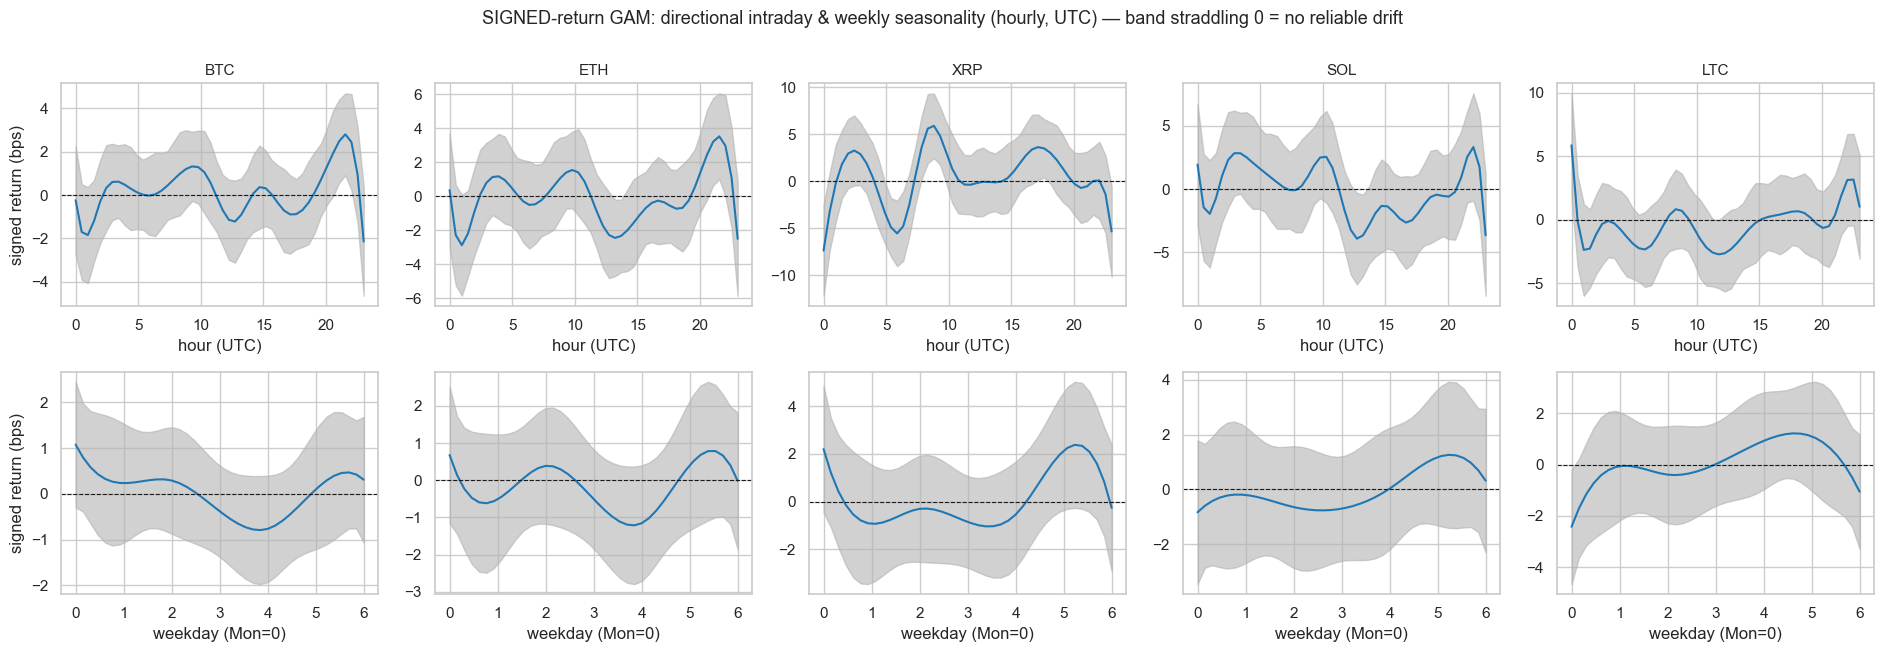

In [9]:
# --- Companion: SIGNED-return GAM (directional seasonality; unlike |ret|, this can cross zero) ---
# Same smooths, but on the raw signed log return: hours/days where the curve sits away from 0 with a
# CI that excludes 0 are a tradeable directional drift; where the band straddles 0 it's just noise.
def signed_frame(tk):
    d = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk') if tk == 'XRP'
         else panel.xs(tk + 'USDT', axis=1, level='Ticker')[['Close']])
    d = d.dropna(subset=['Close'])
    f = pd.DataFrame(index=d.index)
    f['ret']  = np.log(d.Close).diff()
    f['hour'] = d.index.hour
    f['wday'] = d.index.dayofweek
    return f.dropna()

signed_frames = {c: signed_frame(c) for c in GAM_COINS}

fig, axes = plt.subplots(2, 5, figsize=(19, 6.5))
for j, c in enumerate(GAM_COINS):
    f = signed_frames[c]
    g = LinearGAM(s(0, n_splines=14)).fit(f[['hour']].values, f['ret'].values * 1e4)
    xx = g.generate_X_grid(term=0, n=48); ci = g.confidence_intervals(xx)
    ax = axes[0, j]; ax.plot(xx[:, 0], g.predict(xx), 'tab:blue')
    ax.fill_between(xx[:, 0], ci[:, 0], ci[:, 1], color='0.7', alpha=.6)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(c, fontsize=11); ax.set_xlabel('hour (UTC)')
    if j == 0: ax.set_ylabel('signed return (bps)')
    g2 = LinearGAM(s(0, n_splines=6)).fit(f[['wday']].values, f['ret'].values * 1e4)
    xw = g2.generate_X_grid(term=0, n=40); cw = g2.confidence_intervals(xw)
    ax = axes[1, j]; ax.plot(xw[:, 0], g2.predict(xw), 'tab:blue')
    ax.fill_between(xw[:, 0], cw[:, 0], cw[:, 1], color='0.7', alpha=.6)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('weekday (Mon=0)'); ax.set_xticks(range(7))
    if j == 0: ax.set_ylabel('signed return (bps)')
fig.suptitle('SIGNED-return GAM: directional intraday & weekly seasonality (hourly, UTC) — '
             'band straddling 0 = no reliable drift', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

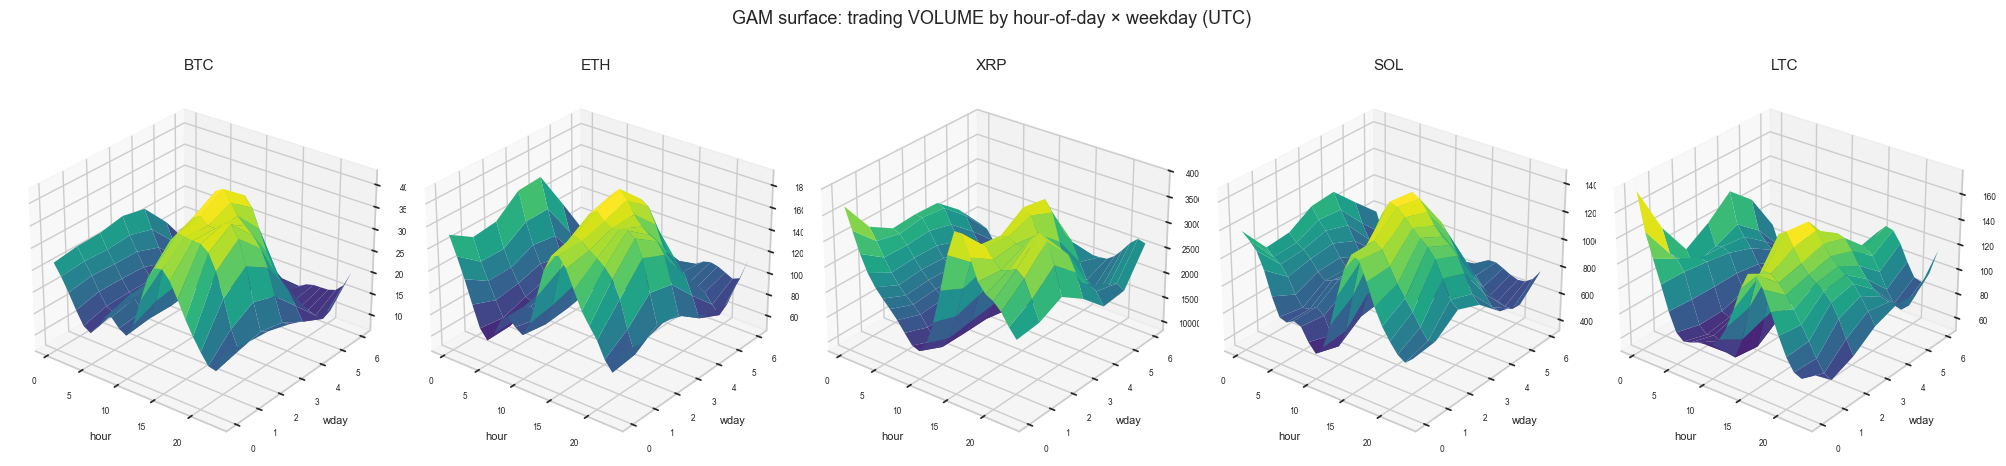

In [10]:
# --- Fig 9: trading VOLUME as a GAM surface over (hour-of-day x weekday) ---
Hgrid, Wgrid = np.meshgrid(np.linspace(0, 23, 24), np.linspace(0, 6, 7))

def gam_surface(field, scale, title):
    fig = plt.figure(figsize=(20, 4.6))
    for j, c in enumerate(GAM_COINS):
        f = gam_frames[c]
        g = LinearGAM(te(0, 1, n_splines=[12, 6])).fit(f[['hour', 'wday']].values, f[field].values * scale)
        Z = g.predict(np.c_[Hgrid.ravel(), Wgrid.ravel()]).reshape(Hgrid.shape)
        ax = fig.add_subplot(1, 5, j + 1, projection='3d')
        ax.plot_surface(Hgrid, Wgrid, Z, cmap=cm.viridis, antialiased=True, linewidth=0)
        ax.set_title(c, fontsize=11); ax.set_xlabel('hour', fontsize=8); ax.set_ylabel('wday', fontsize=8)
        ax.tick_params(labelsize=6); ax.view_init(elev=28, azim=-52)
    fig.suptitle(title, y=1.02, fontsize=13); fig.tight_layout(); plt.show()

gam_surface('volume', 1.0, 'GAM surface: trading VOLUME by hour-of-day × weekday (UTC)')

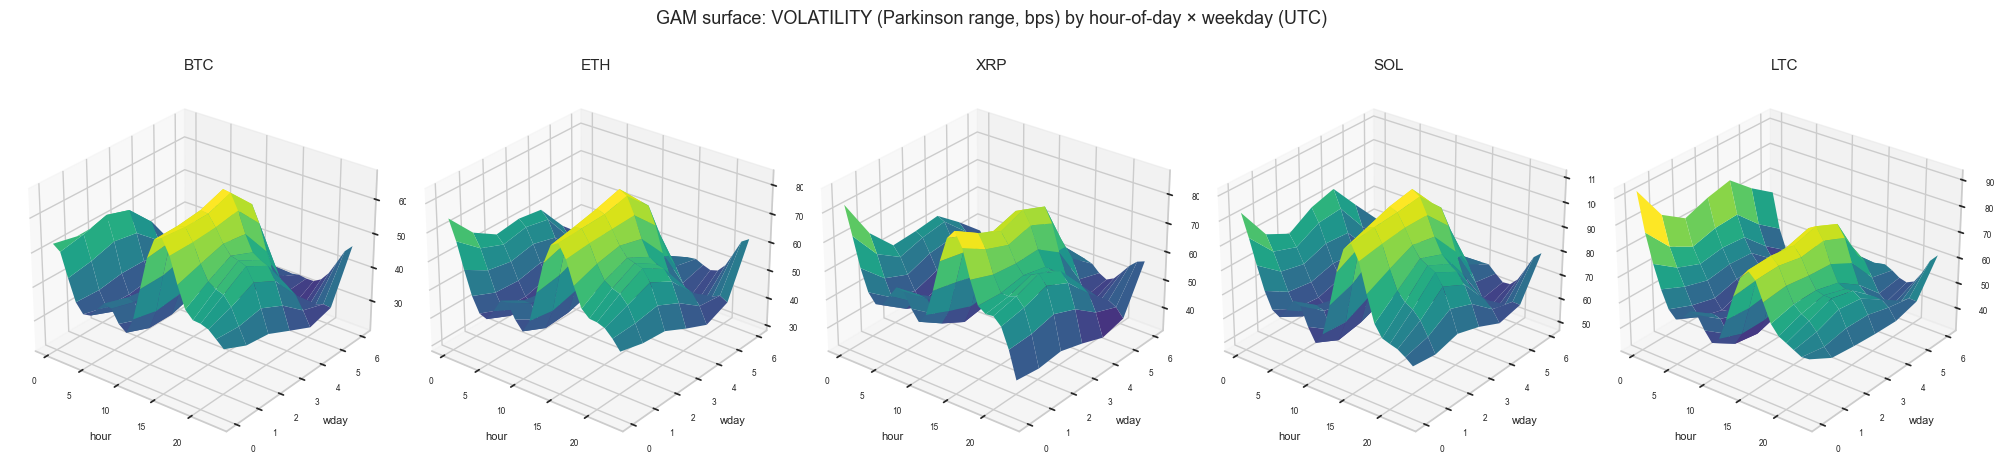

In [11]:
# --- Fig 10: VOLATILITY (Parkinson range) as a GAM surface over (hour-of-day x weekday) ---
gam_surface('parkvol', 1e4, 'GAM surface: VOLATILITY (Parkinson range, bps) by hour-of-day × weekday (UTC)')

## Real order-book spread & illiquidity (Binance.US quotes)

The klines carry no bid/ask, so we poll `get_orderbook_tickers()` for the **real** best bid/ask and
compute the true spread `(ask − bid)/mid`, plus **top-of-book depth** (`bid$`, `ask$`) as a second
illiquidity axis. Snapshots accumulate in `data/orderbook_spread_snapshots.csv` via
`collect_spreads.py` (a cron job polls every 15 min).

**Why real quotes, not an estimator:** OHLC-based spread estimators fail badly here. Corwin-Schultz and
Abdi-Ranaldo both correlate **≈ −0.19** with the real spread — they *overstate* liquid coins (their
high-low range is dominated by volatility) and *understate* dead coins (whose range collapses because
nothing trades). Reality: BTC/SOL/ETH ≈ **2 bps**, while dead microcaps run **hundreds to thousands** of bps.

**Limitation:** Binance has no free historical order book, so this is **live/forward** data — it measures
*current* tradability, not the 2022–2026 backtest window. Run the collector for a while to build real
intraday spread history.

In [12]:
# --- Real order-book spread & depth per coin (from accumulated snapshots; live fallback) ---
_snap = DATA_DIR / 'orderbook_spread_snapshots.csv'
if _snap.exists():
    snaps = pd.read_csv(_snap)
else:                                                    # fallback: one live snapshot
    from binance.client import Client
    snaps = pd.DataFrame(Client(tld='US').get_orderbook_tickers())
    snaps = snaps[snaps.symbol.str.endswith('USDT')].astype(
        {'bidPrice': float, 'askPrice': float, 'bidQty': float, 'askQty': float})
    snaps['mid'] = (snaps.bidPrice + snaps.askPrice) / 2
    snaps = snaps[snaps.mid > 0]
    snaps['spread_bps'] = (snaps.askPrice - snaps.bidPrice) / snaps.mid * 1e4
    snaps['bid_usd'] = snaps.bidPrice * snaps.bidQty
    snaps['ask_usd'] = snaps.askPrice * snaps.askQty

snaps = snaps[snaps.symbol.isin(logret.columns)]
g = snaps.groupby('symbol')
real = pd.DataFrame({'spread_bps': g['spread_bps'].median(),
                     'depth_usd':  (g['bid_usd'].median() + g['ask_usd'].median()) / 2})
real_spread = real['spread_bps'].copy()                  # per-symbol, for use as a cost input
real_spread.to_pickle(DATA_DIR / 'real_spread_bps.pk')
TRADEABLE = real_spread[real_spread < 10].index.tolist() # "cheap enough to trade" universe

n_snaps = snaps['ts_utc'].nunique() if 'ts_utc' in snaps else 1
real.index = [s[:-4] for s in real.index]
real = real.sort_values('spread_bps')
print(f'{n_snaps} snapshot(s), {len(real)} coins | median real spread = {real.spread_bps.median():.1f} bps')
print(f'tradeable (real spread < 10 bps): {len(TRADEABLE)} -> {sorted(s[:-4] for s in TRADEABLE)}')
display(real.round(1))

242 snapshot(s), 60 coins | median real spread = 87.0 bps
tradeable (real spread < 10 bps): 9 -> ['ADA', 'AVAX', 'BNB', 'BTC', 'DOGE', 'ETH', 'LTC', 'SOL', 'ZEC']


,spread_bps,depth_usd
BTC,0.5000,"1,675.7000"
ETH,0.6000,"1,470.3000"
SOL,2.0000,"1,755.5000"
BNB,3.2000,700.4000
DOGE,4.6000,"1,060.0000"
LTC,6.2000,125.6000
ZEC,7.0000,412.1000
AVAX,8.3000,197.1000
ADA,8.6000,200.0000
LINK,10.2000,199.9000


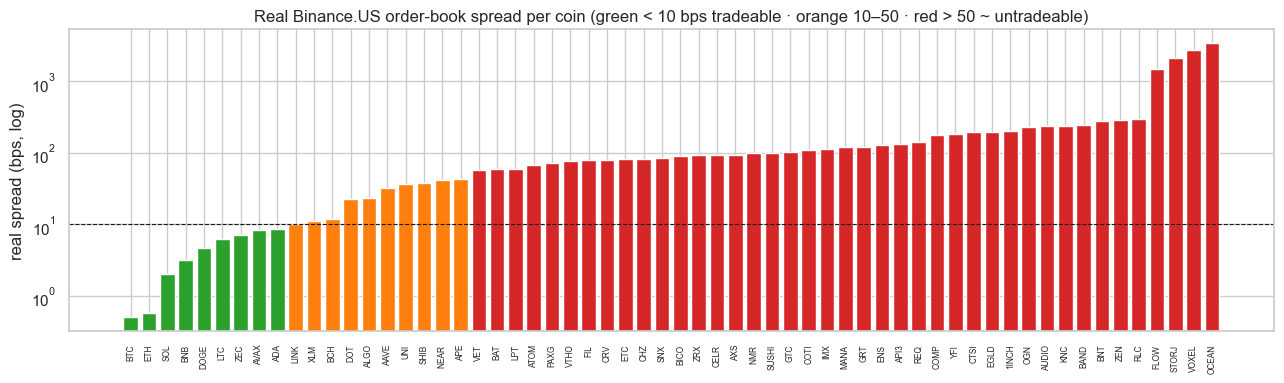

spread bands: <10bps 9 coins | 10-50bps 10 | >50bps 41 coins
=> only a handful are genuinely liquid on Binance.US; most of the 60 are costly-to-untradeable.


In [13]:
# --- Picture: real spread per coin (log), tradeable band highlighted ---
rs = real['spread_bps'].sort_values()
colors = ['tab:green' if v < 10 else ('tab:orange' if v < 50 else 'tab:red') for v in rs.values]
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(rs)), rs.values, color=colors)
ax.set_yscale('log'); ax.axhline(10, color='k', ls='--', lw=0.8)
ax.set_xticks(range(len(rs))); ax.set_xticklabels(rs.index, rotation=90, fontsize=6)
ax.set_ylabel('real spread (bps, log)')
ax.set_title('Real Binance.US order-book spread per coin '
             '(green < 10 bps tradeable · orange 10–50 · red > 50 ~ untradeable)')
fig.tight_layout(); plt.show()
print(f'spread bands: <10bps {int((rs<10).sum())} coins | 10-50bps {int(((rs>=10)&(rs<50)).sum())} | '
      f'>50bps {int((rs>=50).sum())} coins')
print('=> only a handful are genuinely liquid on Binance.US; most of the 60 are costly-to-untradeable.')

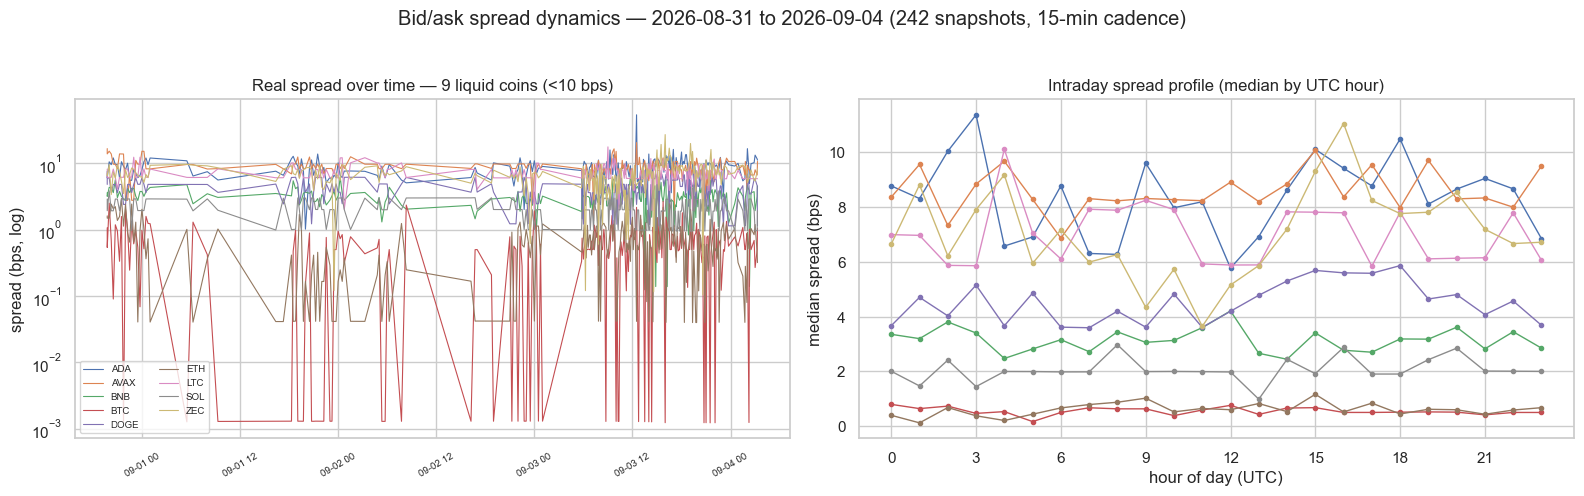

In [14]:
# --- Bid/ask spread OVER TIME: intraday dynamics from the accumulated snapshots ---
snaps_t = pd.read_csv(DATA_DIR / 'orderbook_spread_snapshots.csv', parse_dates=['ts_utc'])
snaps_t = snaps_t[snaps_t.symbol.isin(logret.columns)]
liquid  = real_spread[real_spread < 10].index.tolist()          # tradeable coins (from the loader above)
wide    = snaps_t.pivot_table(index='ts_utc', columns='symbol', values='spread_bps')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8))
# (left) spread time series for the liquid coins
for s in liquid:
    ax1.plot(wide.index, wide[s], lw=0.8, label=s[:-4])
ax1.set_yscale('log'); ax1.set_ylabel('spread (bps, log)')
ax1.set_title(f'Real spread over time — {len(liquid)} liquid coins (<10 bps)')
ax1.legend(ncol=2, fontsize=7); ax1.tick_params(axis='x', labelrotation=30, labelsize=7)
# (right) intraday profile: median spread by UTC hour (robust to the short sample)
byhour = (snaps_t.assign(hour=snaps_t.ts_utc.dt.hour)
                 .groupby(['hour', 'symbol'])['spread_bps'].median().unstack())
for s in liquid:
    ax2.plot(byhour.index, byhour[s], marker='o', ms=3, lw=1, label=s[:-4])
ax2.set_xlabel('hour of day (UTC)'); ax2.set_ylabel('median spread (bps)')
ax2.set_title('Intraday spread profile (median by UTC hour)'); ax2.set_xticks(range(0, 24, 3))
fig.suptitle(f'Bid/ask spread dynamics — {snaps_t.ts_utc.min():%Y-%m-%d} to {snaps_t.ts_utc.max():%Y-%m-%d} '
             f'({snaps_t.ts_utc.nunique()} snapshots, 15-min cadence)', y=1.03)
fig.tight_layout(); plt.show()